# Milestone 1 — Genome, Serializer, Fitness & Visualizer

Recreating the Xenobot pipeline (Kriegman et al., 2020).
This notebook walks through every module built in Milestone 1, with live outputs.

| Module | What it does |
|---|---|
| `genome.py` | Create random 8×8×8 genomes, repair connectivity (LCC) |
| `serializer.py` | Convert genome → VXA XML for voxelyze |
| `fitness.py` | Run voxelyze subprocess, return CoM displacement score |
| `visualize.py` | 3D PyVista renders + connectivity statistics |


## 0 · Setup

In [1]:
import sys, os

# Ensure the project root is on the path when running from notebooks/
PROJECT_ROOT = os.path.abspath("..")
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

# Point to the voxelyze binary
os.environ.setdefault("VOXCRAFT_BIN", os.path.join(PROJECT_ROOT, "voxelyze"))

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from IPython.display import Image, display

print("Python:", sys.version.split()[0])
print("NumPy:", np.__version__)
print("VOXCRAFT_BIN:", os.environ["VOXCRAFT_BIN"])


Python: 3.11.15
NumPy: 2.4.4
VOXCRAFT_BIN: /Users/hiremath/Documents/Projects_AI/xenobot_evolution/voxelyze


## 1 · Genome Representation

The genome is an **8×8×8 NumPy integer array** where each voxel holds:

| Value | Material | Role |
|---|---|---|
| `0` | empty | no voxel here |
| `1` | passive | structural material (grey) |
| `2` | active+ | expands on heat (red) |
| `3` | active− | contracts on heat (blue) |

`random_genome(rng)` fills the grid uniformly at random from {0, 1, 2, 3}.


In [2]:
from src.milestone1.genome import random_genome, largest_connected_component, voxel_counts

rng = np.random.default_rng(42)
g = random_genome(rng)

print("Shape :", g.shape)
print("dtype :", g.dtype)
print("Values:", np.unique(g))
print()
print("Voxel counts:", voxel_counts(g))


Shape : (8, 8, 8)
dtype : int64
Values: [0 1 2 3]

Voxel counts: {'empty': 125, 'passive': 137, 'active_plus': 122, 'active_minus': 128}


### 1.1 · Largest Connected Component (LCC)

Disconnected voxels cannot be simulated properly — isolated chunks would fly off.
`largest_connected_component()` uses **6-connectivity** (`scipy.ndimage.label`) to keep
only the biggest contiguous body, zeroing everything else.

Below we build a genome with two blobs separated by empty space, then repair it.


In [4]:
# Construct a genome with TWO disconnected bodies
disconnected = np.zeros((8, 8, 8), dtype=int)
disconnected[0:3, 0:3, 0:3] = 1   # small 3×3×3 block (27 voxels)
disconnected[5:8, 5:8, 5:8] = 2   # another 3×3×3 block (27 voxels) — disconnected

before = voxel_counts(disconnected)
repaired = largest_connected_component(disconnected)
after  = voxel_counts(repaired)

print("Before LCC repair:", before)
print("After  LCC repair:", after)
print(f"\nIsolated voxels removed: {sum(before[k] for k in ('passive','active_plus','active_minus')) - sum(after[k] for k in ('passive','active_plus','active_minus'))}")


Before LCC repair: {'empty': 458, 'passive': 27, 'active_plus': 27, 'active_minus': 0}
After  LCC repair: {'empty': 485, 'passive': 27, 'active_plus': 0, 'active_minus': 0}

Isolated voxels removed: 27


### 1.2 · Stats on a random genome

Real random genomes at 75% occupancy are almost never disconnected —
the grid is dense enough that one large connected component dominates.


In [5]:
rng2 = np.random.default_rng(42)
results = []
for _ in range(200):
    g = random_genome(rng2)
    g_lcc = largest_connected_component(g)
    total = int(np.sum(g > 0))
    lcc   = int(np.sum(g_lcc > 0))
    results.append((total, lcc, total - lcc))

totals, lccs, removed = zip(*results)
print(f"Over 200 random genomes:")
print(f"  Mean occupied voxels : {np.mean(totals):.1f}")
print(f"  Mean LCC size        : {np.mean(lccs):.1f}")
print(f"  Mean voxels removed  : {np.mean(removed):.2f}")
print(f"  Max voxels removed   : {max(removed)}")


Over 200 random genomes:
  Mean occupied voxels : 383.9
  Mean LCC size        : 383.2
  Mean voxels removed  : 0.63
  Max voxels removed   : 8


## 2 · VXA Serializer

`genome_to_vxa()` converts a genome array into the XML format voxelyze expects.
Key design choices locked in:

- Material properties live inside a **`<Mechanical>`** wrapper (required by voxelyze's parser)
- **active−** uses `CTE = -0.01` (contracts on heat) — *not* `PhaseOffset`, which is a per-voxel data block in this version of voxelyze
- The `<GA><FitnessFileName>` tag tells voxelyze where to write its result XML
- Voxel data: ASCII CDATA, **row-major X→Y**, one `<Layer>` per Z slice


In [6]:
from src.milestone1.serializer import genome_to_vxa, vxa_to_file

rng3 = np.random.default_rng(7)
sample = random_genome(rng3)
sample = largest_connected_component(sample)

vxa = genome_to_vxa(sample, sim_time=1.0, fitness_file="/tmp/demo_output.xml")

# Print the first 50 lines for inspection
lines = vxa.strip().split("\n")
print(f"Total lines: {len(lines)}")
print("\n".join(lines[:50]))
print("...")


Total lines: 111
<?xml version="1.0" encoding="ISO-8859-1"?>
<VXA Version="1.0">
  <Simulator>
    <Integration>
      <Integrator>0</Integrator>
      <DtFrac>0.9</DtFrac>
    </Integration>
    <Damping>
      <BondDampingZ>1</BondDampingZ>
      <ColDampingZ>0.8</ColDampingZ>
      <SlowDampingZ>1.7378e-005</SlowDampingZ>
    </Damping>
    <StopCondition>
      <StopConditionType>2</StopConditionType>
      <StopConditionValue>1.0</StopConditionValue>
    </StopCondition>
    <GA>
      <FitnessFileName>/tmp/demo_output.xml</FitnessFileName>
      <WriteFitnessFile>true</WriteFitnessFile>
    </GA>
  </Simulator>
  <Environment>
    <Fixed_Regions><NumFixed>0</NumFixed></Fixed_Regions>
    <Forced_Regions><NumForced>0</NumForced></Forced_Regions>
    <Gravity>
      <GravEnabled>1</GravEnabled>
      <GravAcc>-9.81</GravAcc>
      <FloorEnabled>1</FloorEnabled>
    </Gravity>
    <Thermal>
      <TempEnabled>1</TempEnabled>
      <TempAmp>39</TempAmp>
      <TempBase>25</TempBase>


In [7]:
import tempfile, xml.etree.ElementTree as ET

# Confirm it is valid XML
ET.fromstring(vxa)
print("✅ Valid XML")

# Confirm no PhaseOffset tag (we use negative CTE instead)
assert "PhaseOffset" not in vxa
print("✅ No PhaseOffset tag")

# Confirm Material ID=0 (empty) is not in the palette
root = ET.fromstring(vxa)
assert root.find(".//Material[@ID='0']") is None
print("✅ Empty voxels not in material palette")

# Confirm active- has negative CTE
mat3 = root.find(".//Material[@ID='3']")
cte_val = float(mat3.find(".//CTE").text)
assert cte_val < 0
print(f"✅ Active− CTE = {cte_val} (negative → contracts)")


✅ Valid XML
✅ No PhaseOffset tag
✅ Empty voxels not in material palette
✅ Active− CTE = -0.01 (negative → contracts)


In [8]:
# Write to disk
with tempfile.TemporaryDirectory() as tmp:
    path = os.path.join(tmp, "genome.vxa")
    vxa_to_file(sample, path, sim_time=1.0)
    size = os.path.getsize(path)
    print(f"✅ vxa_to_file wrote {size} bytes to {path}")
    print(f"   Companion output path: {os.path.splitext(path)[0]}_output.xml")


✅ vxa_to_file wrote 3823 bytes to /var/folders/ht/7j3cnmfx6q59qmm8sklsd8rh0000gn/T/tmp4n9jf5d2/genome.vxa
   Companion output path: /var/folders/ht/7j3cnmfx6q59qmm8sklsd8rh0000gn/T/tmp4n9jf5d2/genome_output.xml


## 3 · Fitness Evaluator

`evaluate_genome()` runs voxelyze as a subprocess and returns **NormFinalDist** —
normalised centre-of-mass displacement (higher = moves farther).

Pipeline per call:
1. Write genome as `.vxa` to a temp directory
2. Call `voxelyze -f robot.vxa` (output path is embedded in the VXA)
3. Parse `<NormFinalDist>` from the result XML
4. Return `max(0.0, value)`

Short-circuit rules (return `0.0` immediately, no sim cost):
- Fewer than 8 non-empty voxels
- No active voxels (can't move)


In [9]:
from src.milestone1.fitness import evaluate_genome

# Case 1: empty genome → 0.0, no sim needed
empty = np.zeros((8, 8, 8), dtype=int)
score = evaluate_genome(empty)
print(f"Empty genome score : {score}")
assert score == 0.0


Empty genome score : 0.0


In [10]:
# Case 2: solid passive block → 0.0 (no active material)
passive_only = np.ones((8, 8, 8), dtype=int)
score = evaluate_genome(passive_only)
print(f"All-passive score  : {score}")
assert score == 0.0


All-passive score  : 0.0


In [11]:
# Case 3: 4×4×4 checkerboard of active+/active- — should move
mover = np.zeros((8, 8, 8), dtype=int)
for x in range(2, 6):
    for y in range(2, 6):
        for z in range(0, 4):
            mover[x, y, z] = 2 if (x + y + z) % 2 == 0 else 3

print(f"Active voxels: {int(np.sum(mover >= 2))}")
score = evaluate_genome(mover, sim_time=1.0)
print(f"Fitness score : {score:.4f}  (higher = moves farther)")
assert score > 0.0, "Expected non-zero fitness for active block"
print("✅ evaluate_genome working")


Active voxels: 64
Fitness score : 4.3652  (higher = moves farther)
✅ evaluate_genome working


## 4 · Visualizer

Two functions:

| Function | Output |
|---|---|
| `render_genome(genome, save_path)` | 3D PyVista voxel plot (off-screen PNG) |
| `render_connectivity_stats(n)` | Matplotlib bar chart of LCC sizes |

**Color scheme:** passive = grey, active+ = red, active− = blue.


Saved 3D render → ../renders/m1_best_mover.png


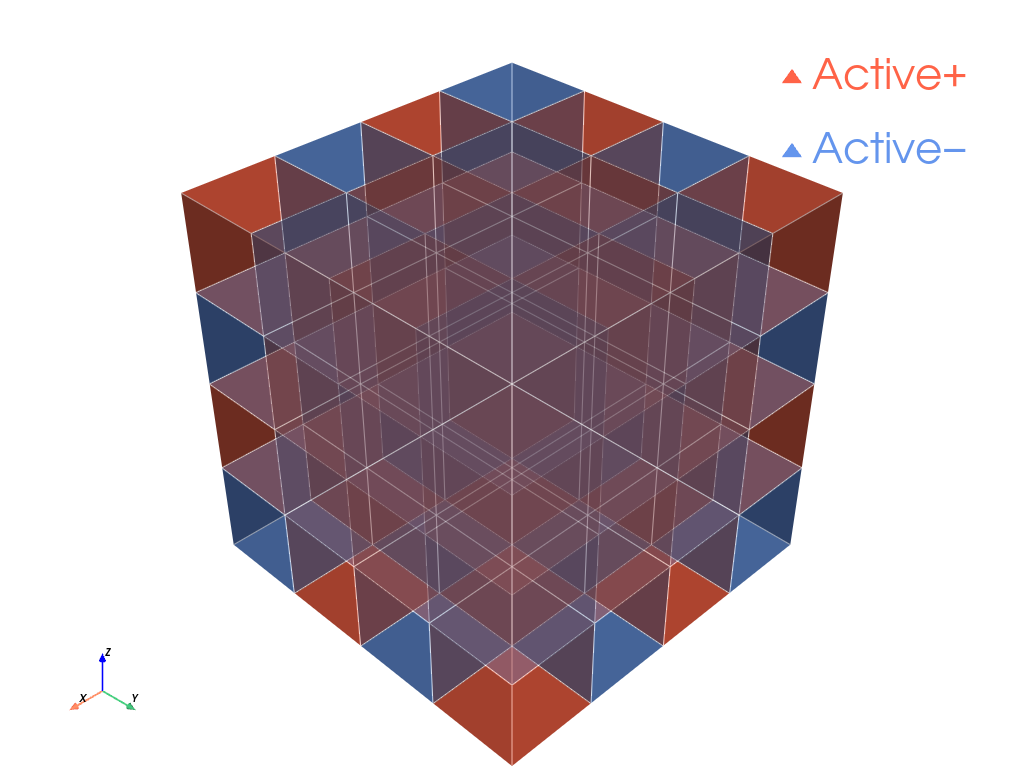

In [12]:
from src.milestone1.visualize import render_genome, render_connectivity_stats

os.makedirs("../renders", exist_ok=True)

# Render the checkerboard mover from Section 3
render_path = "../renders/m1_best_mover.png"
render_genome(mover, save_path=render_path)
print(f"Saved 3D render → {render_path}")
display(Image(render_path, width=500))


Saved random genome render → ../renders/m1_random_genome.png


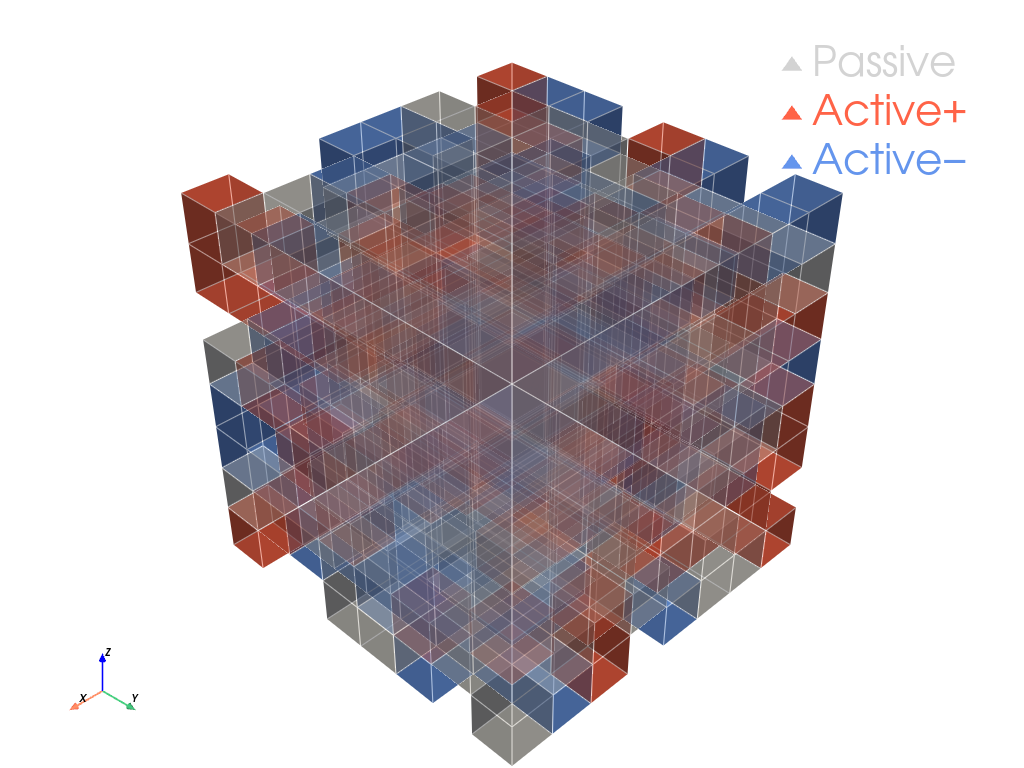

In [13]:
# Render a fully random genome (seed 42) for comparison
rng4 = np.random.default_rng(42)
random_g = largest_connected_component(random_genome(rng4))
random_render = "../renders/m1_random_genome.png"
render_genome(random_g, save_path=random_render)
print(f"Saved random genome render → {random_render}")
display(Image(random_render, width=500))


### 4.1 · Connectivity Statistics

Across 500 random genomes, how large is the LCC?
Dense random genomes (75% occupancy in an 8×8×8 grid) almost always form
one large connected component — mean LCC ≈ 384 voxels out of 512.


Saved results/m1/connectivity.png and results/m1/connectivity.csv
LCC sizes — min: 351, max: 408, mean: 383.7, median: 384


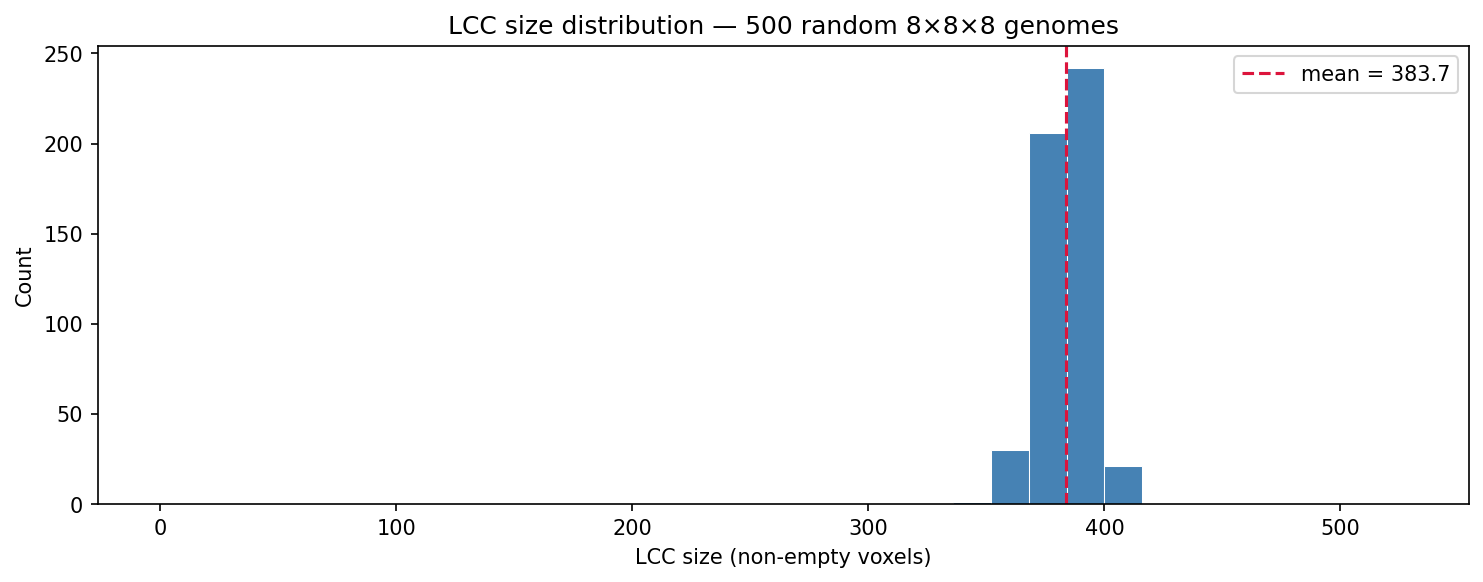

In [14]:
render_connectivity_stats(n_samples=500)

# Display the saved figure inline
display(Image("../results/m1/connectivity.png", width=700))


## 5 · Milestone 1 Summary

| Component | Status | Key facts |
|---|---|---|
| `genome.py` | ✅ | (8,8,8) int array; LCC via 6-connected label; voxel_counts |
| `serializer.py` | ✅ | VXA with `<Mechanical>` wrapper; active− uses CTE=-0.01 |
| `fitness.py` | ✅ | voxelyze subprocess; parses NormFinalDist; short-circuits invalid genomes |
| `visualize.py` | ✅ | PyVista off-screen PNG; Matplotlib connectivity bar chart |

**Next: Milestone 2** — DEAP mutation/crossover operators and the full EA loop.
